In [1]:
import elbow
import numpy
import matplotlib.pyplot as pyplot
import pandas
import sklearn.datasets as datasets
from sklearn.preprocessing import StandardScaler
import seaborn

In [2]:
# We'll try out some of the tests performed by Francisco J. Pérez-Reche in their paper: 
# "The elbow statistic: Multiscale clustering statistical significance".
# We'll use both synthetic and real data sets where we know the number of groups.

# We'll start by simulating 2D data using a Gaussian Mixture distribution.

In [3]:
def sample_gaussian_mixture(d=2, m=3, sigma=1, n=200, bounds=(-10, 10), set_rng=None):
    if set_rng is not None:
        numpy.random.seed(set_rng)

    means = numpy.zeros((m, d))
    covariance = sigma * numpy.eye(d)
    mixtures = numpy.arange(m)
    for i in mixtures:
        means[i] = numpy.random.uniform(bounds[0], bounds[1], size=(d,))
    
    x = numpy.zeros((n, d))
    labels = numpy.zeros(n, dtype=int)
    for i in range(n):
        choice = numpy.random.choice(mixtures)
        x[i] = numpy.random.multivariate_normal(means[choice], covariance)
        labels[i] = choice
    return x, labels, means

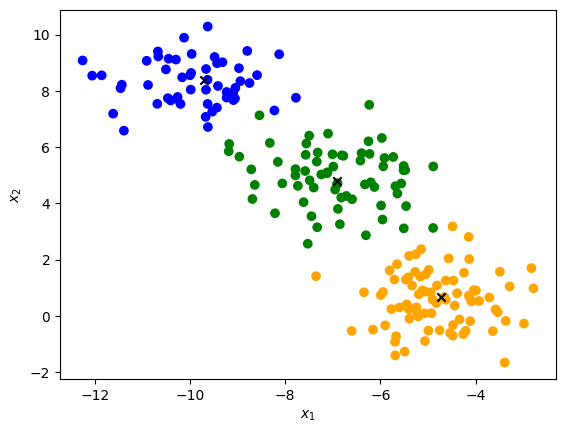

In [6]:
# The means of the three gaussian distributions used to sample from are shown as crosses.
# Each distribution was given an identity matrix for their covariance.

X, Labels, Means = sample_gaussian_mixture(set_rng=12)
colors = numpy.array(['green', 'orange', 'blue'])
pyplot.scatter(X[:, 0], X[:, 1], c=colors[Labels])
pyplot.xlabel('$x_1$')
pyplot.ylabel('$x_2$')
pyplot.scatter(Means[:, 0], Means[:, 1], marker='x', c='black');

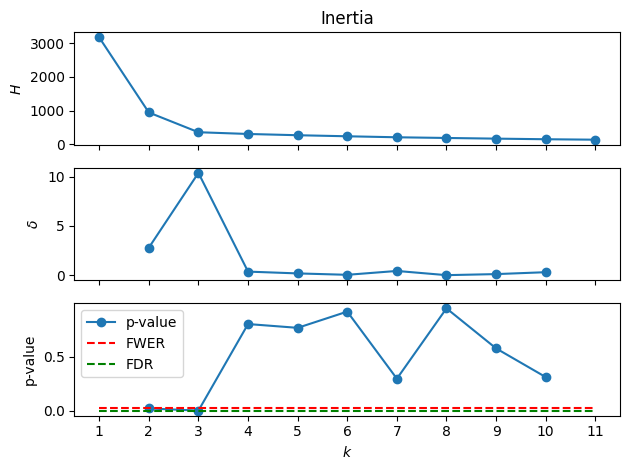

In [7]:
# Agglomerative Clustering with Ward linkage was used with N = 200 monte-carlo simulations of uniformly
# distributed data on the same ranges.

agglomerative = elbow.Agglomerative(linkage='ward')
agglomerative.fit(X)
agglomerative.find_significant_k(X, N=200, set_rng=21)
agglomerative.plot()

In [8]:
agglomerative.show_significant_k()

FWER: [3]
FDR: [3]


In [9]:
# Our model selects only a cluster size k of 3 for both the Family-Wise Error Rate and False Discovery Rate
# p-threshold methods. 

# We can visulize these results.

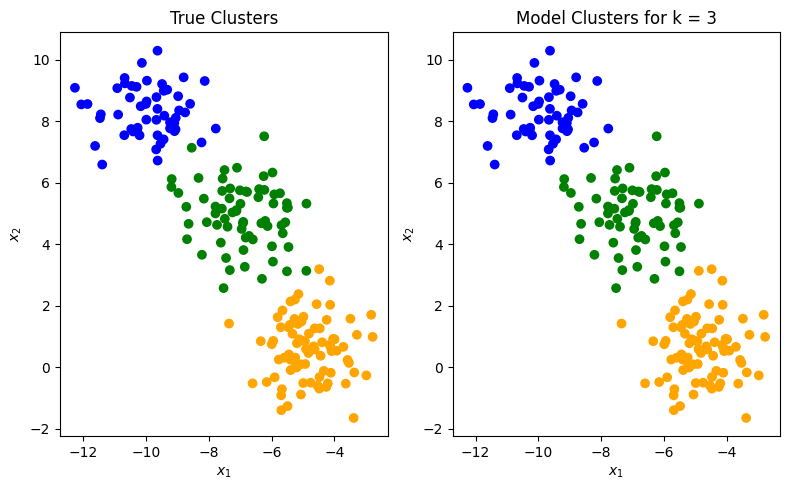

In [11]:
figure, axes = pyplot.subplots(1, 2, figsize=(8, 5))
axes[0].scatter(X[:, 0], X[:, 1], c=colors[Labels])
axes[0].set_xlabel('$x_1$')
axes[0].set_ylabel('$x_2$')
axes[0].set_title('True Clusters')

# permute the colours so the plots match
colors_alt = numpy.array(['orange', 'green', 'blue'])
axes[1].scatter(X[:, 0], X[:, 1], c=colors_alt[agglomerative.get_labels(3)])
axes[1].set_title('Model Clusters for k = 3')
axes[1].set_xlabel('$x_1$')
axes[1].set_ylabel('$x_2$')
figure.tight_layout();

In [10]:
# We'll repeat this for other data dimensions D, number of gaussian distributions M and 
# covariance matrices as done in the paper.

D = [2, 5, 5, 20]
M = [3, 3, 3, 5]

# The covriance matrix will be an element of sigma times an identity matrix.
Sigma = [1, 1, 4, 1]

k_vals = numpy.arange(2, 11).astype(str)
k_map = {k: str(k) for k in range(2, 11)}

columns = ['D', 'M', 'sigma', 'Method'] + list(k_vals)
result_dataframe = pandas.DataFrame(columns=columns)
FWER_row = ['FWER'] + [0] * k_vals.shape[0]
FDR_row = ['FDR'] + [0] * k_vals.shape[0]
agglomerative = elbow.Agglomerative(linkage='ward')


count = 0
for j in range(len(D)):
    result_dataframe.loc[count] = [D[j], M[j], Sigma[j]] + FWER_row
    result_dataframe.loc[count + 1] = [D[j], M[j], Sigma[j]] + FDR_row
    
    for _ in range(100):
        X, _, _ = sample_gaussian_mixture(D[j], M[j], Sigma[j])
        agglomerative.fit(X)
        agglomerative.find_significant_k(X, N=200, use_pca=True, show_progress=False)

        for k in agglomerative.significant_k_FWER:
            result_dataframe.loc[count, k_map[k]] += 1

        for k in agglomerative.significant_k_FDR:
            result_dataframe.loc[count + 1, k_map[k]] += 1
        
    count += 2

result_dataframe.style.hide(axis='index')

D,M,sigma,Method,2,3,4,5,6,7,8,9,10
2,3,1,FWER,32,87,1,0,0,0,0,1,0
2,3,1,FDR,34,90,1,0,0,0,0,1,0
5,3,1,FWER,13,99,0,0,0,0,0,0,0
5,3,1,FDR,13,99,0,0,0,0,0,0,0
5,3,4,FWER,8,99,0,0,0,0,0,0,0
5,3,4,FDR,10,100,0,0,0,0,0,0,0
20,5,1,FWER,0,0,0,100,0,0,0,0,0
20,5,1,FDR,0,0,0,100,0,0,0,0,0


In [ ]:
# For each combination of D, M and sigma, we simulated 100 data sets. We then counted the number of times
# our agglomerative clustering model decided that a certain k is significant under either a FWER or FDR
# method.

# We see that for M = 3, our model mostly selects k = 3 as well. And sometimes it finds k = 2 significant
# as well (most likely when two of the guassian means end up close enough for the groups to mix).

# While for M = 5 and D = 20, our model only selects k = 5 as significant. This is probably because in
# the higher dimensional space, the gaussian means end up farther apart in terms of distance.

In [12]:
# Now we'll comparing different clustering models with D = 5, M = 3 and a sigma of 1.

columns = ['Cluster Method', 'Reference', 'Control'] + list(k_vals)
result_dataframe = pandas.DataFrame(columns=columns)
kmeans = elbow.KMeans(n_init='auto')
fuzzy = elbow.FuzzyCMeans()
gaussian_mix = elbow.GaussianMixture()

models = [agglomerative, kmeans, fuzzy, gaussian_mix]
names = ['Agglomerative', 'K-means', 'Fuzzy c-means', 'Gaussian Mixture Model']
references = ['BBU', 'PCA']
pca_map = {'BBU':False, 'PCA':True}
controls = ['FWER', 'FDR']

count = 0
for name in names:
    for ref in references:
        for control in controls:
            result_dataframe.loc[count] = [name, ref, control] + [0] * k_vals.shape[0]
            count += 1

iterations = 100
for j in range(iterations):
    X, _, _ = sample_gaussian_mixture(5, 3, 1)
    count = 0
    
    for i in range(4):     
        model = models[i]
        model.fit(X)
        
        for ref in references:
            model.find_significant_k(X, N=200, use_pca=pca_map[ref], show_progress=False)
            for k in model.significant_k_FWER:
                result_dataframe.loc[count, k_map[k]] += 1
            for k in model.significant_k_FDR:
                result_dataframe.loc[count + 1, k_map[k]] += 1
            count += 2

    print('Completed', j + 1, 'out of', iterations, end='\r')

result_dataframe.style.hide(axis='index')

Cluster Method,Reference,Control,2,3,4,5,6,7,8,9,10
Agglomerative,BBU,FWER,25,100,0,0,0,0,0,0,0
Agglomerative,BBU,FDR,27,100,0,0,0,0,0,0,0
Agglomerative,PCA,FWER,6,100,0,0,0,0,0,0,0
Agglomerative,PCA,FDR,6,100,0,0,0,0,0,0,0
K-means,BBU,FWER,22,100,2,1,2,0,1,0,1
K-means,BBU,FDR,24,100,2,2,2,0,1,1,2
K-means,PCA,FWER,4,100,2,1,3,1,0,2,2
K-means,PCA,FDR,5,100,2,2,4,1,0,2,2
Fuzzy c-means,BBU,FWER,42,99,27,45,29,49,46,42,33
Fuzzy c-means,BBU,FDR,42,99,27,45,30,49,46,43,33


In [ ]:
# BBU refers to the model simulating the given data as uniform over its ranges, while PCA instead 
# simlulates the principle components of the data as uniform.

# We see that both Agglomerative and K-means predominantly say k = 3 is significant. 
# They also seem much less likely to select k = 2 under the PCA reference. 

# Fuzzy c-means also regularly picks k = 3 as significant, but it also selects larger values of k as
# significant frequently.

# And the GMM model again mostly just picks k = 3, but it does so less frequently than the first two.

# So this suggests that Agglomerative and K-means clustering work the best with the elbow statistic.

In [13]:
def sample_uniform(d=2, n=200, bounds=(0, 1)):
    return numpy.random.uniform(bounds[0], bounds[1], size=(n, d))

In [17]:
# Here we will see how frequently our agglomerative model decides that no k is significant
# when the data has no clustering pattern to it.

k_vals = numpy.arange(1, 11).astype(str)

columns = ['D', 'Data', 'Reference', 'Control'] + ['None Significant'] + list(k_vals[1:])
result_dataframe = pandas.DataFrame(columns=columns)

D = [2, 20]
model = agglomerative

count = 0
for dim in D:
    for control in controls:
        result_dataframe.loc[count] = [dim, 'Uniform', 'BBU', control] + [0] * k_vals.shape[0]
        count += 1

count = 0
iterations = 100
for dim in D:
    for j in range(iterations):
        X = sample_uniform(d=dim)
        
        model.fit(X)
        model.find_significant_k(X, N=200, use_pca=False, show_progress=False)
        
        if len(model.significant_k_FWER) == 0:
            result_dataframe.loc[count, 'None Significant'] += 1
        else:
            for k in model.significant_k_FWER:
                result_dataframe.loc[count, k_map[k]] += 1
                
        if len(model.significant_k_FDR) == 0:
            result_dataframe.loc[count + 1, 'None Significant'] += 1
        else:
            for k in model.significant_k_FDR:
                result_dataframe.loc[count + 1, k_map[k]] += 1
    count += 2

result_dataframe.style.hide(axis='index')

D,Data,Reference,Control,None Significant,2,3,4,5,6,7,8,9,10
2,Uniform,BBU,FWER,96,1,1,1,0,0,0,1,0,0
2,Uniform,BBU,FDR,96,1,1,1,0,0,0,1,0,0
20,Uniform,BBU,FWER,95,0,3,0,0,0,0,1,1,0
20,Uniform,BBU,FDR,95,0,3,0,0,0,0,1,1,0


In [ ]:
# We can see that the majority of the time, our model finds none of the possible k values significant 
# when the data is truely uniformly distributed.

In [18]:
columns = ['D', 'Data', 'Reference', 'Control'] + ['None Significant'] + list(k_vals[1:])
result_dataframe = pandas.DataFrame(columns=columns)

D = [2, 20]

count = 0
for dim in D:
    for ref in references:
        for control in controls:
            result_dataframe.loc[count] = [dim, 'Gaussian', ref, control] + [0] * k_vals.shape[0]
            count += 1

count = 0
iterations = 100
for dim in D:
    for j in range(iterations):
        X, _, _ = sample_gaussian_mixture(d=dim, m=1)
        
        model.fit(X)
        model.find_significant_k(X, N=200, use_pca=False, show_progress=False)
        
        if len(model.significant_k_FWER) == 0:
            result_dataframe.loc[count, 'None Significant'] += 1
        else:
            for k in model.significant_k_FWER:
                result_dataframe.loc[count, k_map[k]] += 1
                
        if len(model.significant_k_FDR) == 0:
            result_dataframe.loc[count + 1, 'None Significant'] += 1
        else:
            for k in model.significant_k_FDR:
                result_dataframe.loc[count + 1, k_map[k]] += 1
        
        model.find_significant_k(X, N=200, use_pca=True, show_progress=False)
        
        if len(model.significant_k_FWER) == 0:
            result_dataframe.loc[count + 2, 'None Significant'] += 1
        else:
            for k in model.significant_k_FWER:
                result_dataframe.loc[count + 2, k_map[k]] += 1
                
        if len(model.significant_k_FDR) == 0:
            result_dataframe.loc[count + 3, 'None Significant'] += 1
        else:
            for k in model.significant_k_FDR:
                result_dataframe.loc[count + 3, k_map[k]] += 1
    count += 4

result_dataframe.style.hide(axis='index')

D,Data,Reference,Control,None Significant,2,3,4,5,6,7,8,9,10
2,Gaussian,BBU,FWER,92,0,7,0,0,0,0,0,0,1
2,Gaussian,BBU,FDR,92,0,7,0,0,0,0,0,0,2
2,Gaussian,PCA,FWER,94,0,4,0,1,0,0,0,0,1
2,Gaussian,PCA,FDR,94,0,4,0,1,0,0,0,0,1
20,Gaussian,BBU,FWER,92,0,1,0,0,1,0,4,1,1
20,Gaussian,BBU,FDR,92,0,1,0,0,1,0,4,1,1
20,Gaussian,PCA,FWER,98,0,0,0,0,0,0,1,1,0
20,Gaussian,PCA,FDR,98,0,0,0,0,0,0,1,1,0


In [ ]:
# We find similar results for when the data is sampled from a single gaussian distribution. But it seems
# to find significant k values a bit more frequently under BBU than with the previously uniform data. 
# This makes sense as the model compares the data to its uniformly generated versions of it under BBU. 
# So it should be more likely to find significant differences when the data is actually gaussian than 
# when the data is actually uniform.

In [19]:
# Now we'll look at how our models do with real data sets.
kmeans = elbow.KMeans()
agglomerative = elbow.Agglomerative()
gaussian_mix = elbow.GaussianMixture()

references = ['BBU', 'PCA']
pca_map = {'BBU':False, 'PCA':True}
controls = ['FWER', 'FDR']

In [26]:
scaler = StandardScaler()

def real_data_test(dataset, N):
    global scaler, agglomerative, kmeans, gaussian_mix, references, controls, pca_map
    
    X = scaler.fit_transform(dataset.data)
    cols = ['Method', 'Reference', 'Control', 'Significant k']
    dataframe = pandas.DataFrame(columns=cols)

    model_list = [agglomerative, kmeans, gaussian_mix]
    name_list = ['Agglomerative', 'K-means', 'Gaussian Mixture Model']
    
    count = 0
    for name, model in zip(name_list, model_list):
        model.fit(X)
        for ref in references:
            model.find_significant_k(X, N=N, use_pca=pca_map[ref], show_progress=False)
            for control in controls:
                if control == 'FWER':
                    dataframe.loc[count] = [name, ref, control, model.significant_k_FWER]
                else:
                    dataframe.loc[count] = [name, ref, control, model.significant_k_FDR]
                count += 1
    
    return dataframe

In [21]:
# First we'll look at the iris data set.

# 4 dimensions, 3 classes, 150 instances
data_set = datasets.load_iris()

result_dataframe = real_data_test(data_set, 200)
result_dataframe.style.hide(axis='index')

Method,Reference,Control,Significant k
Agglomerative,BBU,FWER,"[2, 5]"
Agglomerative,BBU,FDR,"[2, 5]"
Agglomerative,PCA,FWER,[2]
Agglomerative,PCA,FDR,[2]
K-means,BBU,FWER,[]
K-means,BBU,FDR,[]
K-means,PCA,FWER,[2]
K-means,PCA,FDR,[2]
Gaussian Mixture Model,BBU,FWER,[2]
Gaussian Mixture Model,BBU,FDR,[2]


In [ ]:
# Agglomerative selects 2 or 5 as significant while K-means and GMM select either 2 or none. This seems
# to be at odds with the flowers having 3 classes, but two of the flower types tend to be quite close to
# each other in terms of their features. So finding k = 2 significant isn't too strange.

Iris Data Pair Plots


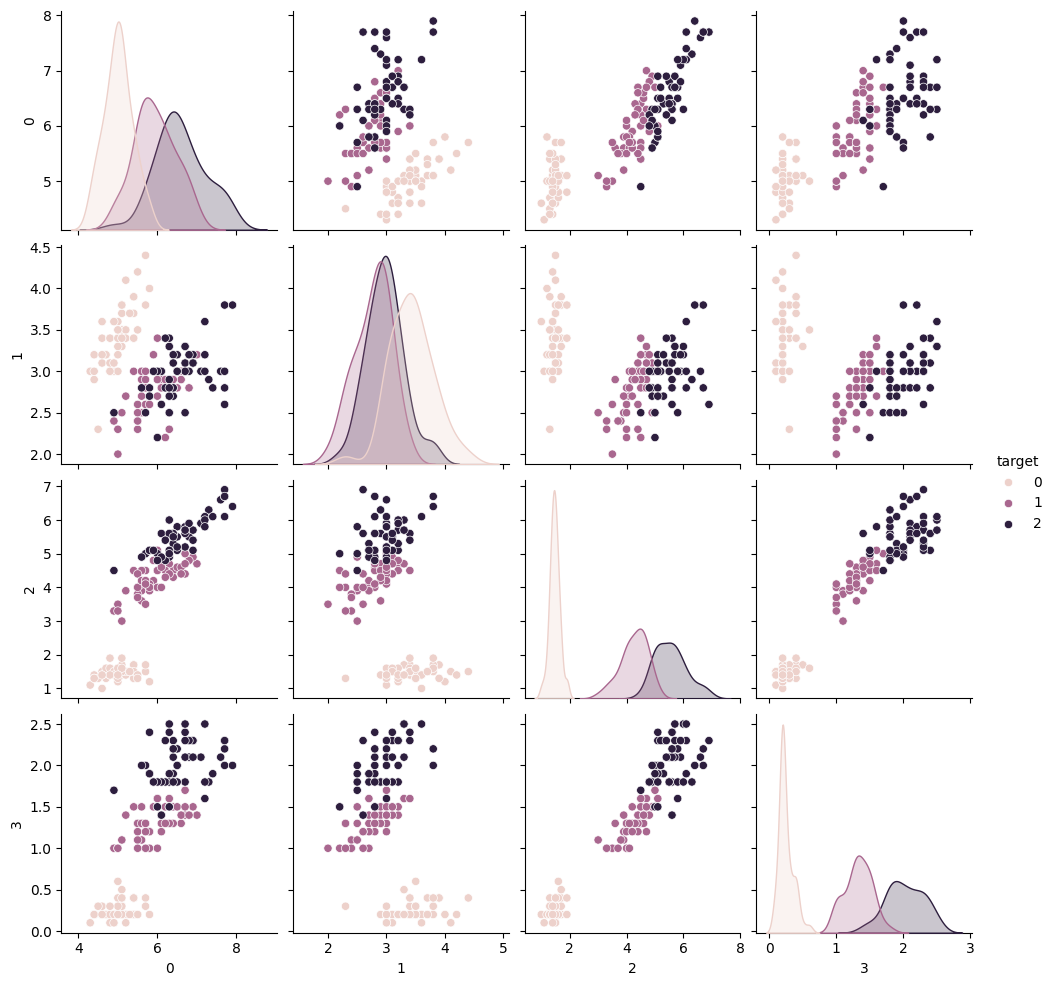

In [18]:
data_frame = pandas.DataFrame(data_set.data)
data_frame['target'] = data_set.target
seaborn.pairplot(data_frame, hue='target');
print('Iris Data Pair Plots')

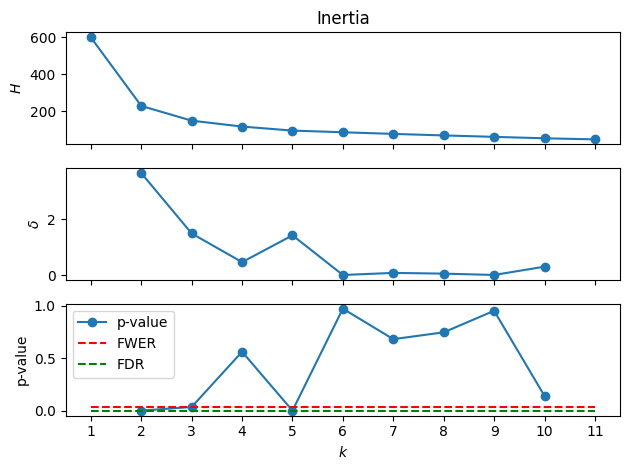

In [30]:
# Also when we look at the p-values for the agglomerative model with BBU,
# we can see that k = 3 just barely doesn't meet our criteria.

X = scaler.fit_transform(data_set.data)
agglomerative.fit(X)
agglomerative.find_significant_k(X, N=200)
agglomerative.plot()

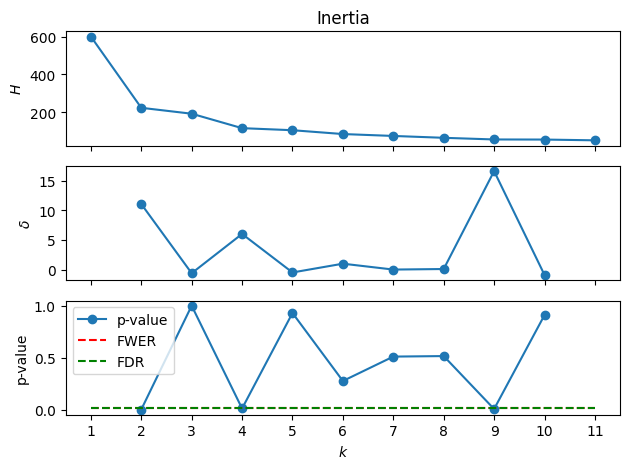

In [33]:
# Although, the kmeans model with BBU does seem to find a huge p-value for k = 3.

kmeans.fit(X)
kmeans.find_significant_k(X, N=200)
kmeans.plot()

In [23]:
# The breast cancer data set.

# 30 dimensions, 2 classes, 569 instances
data_set = datasets.load_breast_cancer()

result_dataframe = real_data_test(data_set, 200)
result_dataframe.style.hide(axis='index')

Method,Reference,Control,Significant k
Agglomerative,BBU,FWER,"[2, 3]"
Agglomerative,BBU,FDR,"[2, 3]"
Agglomerative,PCA,FWER,[2]
Agglomerative,PCA,FDR,"[2, 3]"
K-means,BBU,FWER,[]
K-means,BBU,FDR,[]
K-means,PCA,FWER,[2]
K-means,PCA,FDR,[2]
Gaussian Mixture Model,BBU,FWER,[2]
Gaussian Mixture Model,BBU,FDR,[2]


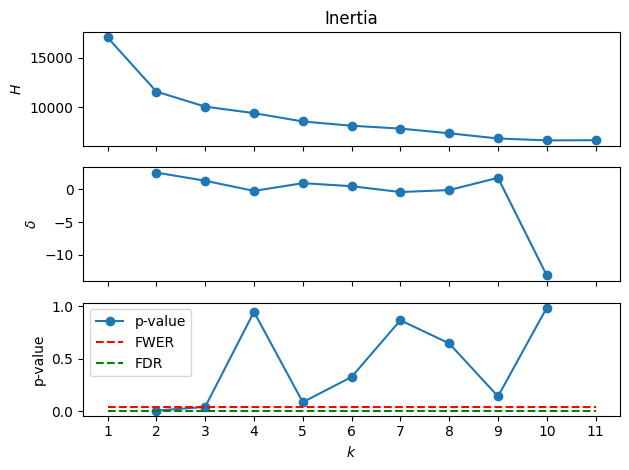

In [36]:
# We can see that 2 is commonly selected to be significant by our models as we would hope for. And 
# a repeat of kmeans with BBU does select k = 2 as significant.

X = scaler.fit_transform(data_set.data)
kmeans.fit(X)
kmeans.find_significant_k(X, N=200)
kmeans.plot()

In [37]:
kmeans.show_significant_k()

FWER: [2]
FDR: [2]


In [24]:
# The paper used other data sets than the other ones we'll use. Their
# remaining data sets seemed annoying/difficult to get.

# The wine data set.

# 13 dimensions, 3 classes, 178 instances
data_set = datasets.load_wine()

result_dataframe = real_data_test(data_set, 200)
result_dataframe.style.hide(axis='index')

Method,Reference,Control,Significant k
Agglomerative,BBU,FWER,"[3, 9]"
Agglomerative,BBU,FDR,"[3, 9]"
Agglomerative,PCA,FWER,[3]
Agglomerative,PCA,FDR,[3]
K-means,BBU,FWER,[3]
K-means,BBU,FDR,[3]
K-means,PCA,FWER,[]
K-means,PCA,FDR,[]
Gaussian Mixture Model,BBU,FWER,[]
Gaussian Mixture Model,BBU,FDR,"[2, 7]"


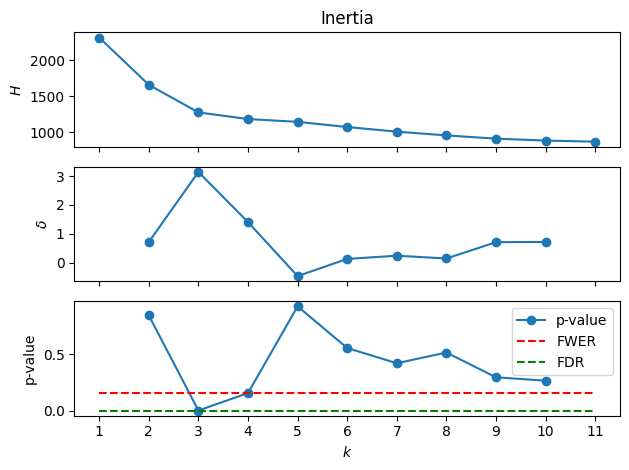

In [38]:
# We see that k = 3 is the most commonly picked by kmeans and agglomerative. And similar to before,
# repeating kmeans with PCA results in selecting k = 3 as significant.

X = scaler.fit_transform(data_set.data)
kmeans.fit(X)
kmeans.find_significant_k(X, use_pca=True, N=200)
kmeans.plot()

In [39]:
kmeans.show_significant_k()

FWER: [3]
FDR: [3]


In [25]:
# The diabetes data set.

# 10 dimensions, 2 classes, 442 instances
data_set = datasets.load_diabetes()

result_dataframe = real_data_test(data_set, 200)
result_dataframe.style.hide(axis='index')

Method,Reference,Control,Significant k
Agglomerative,BBU,FWER,[7]
Agglomerative,BBU,FDR,[7]
Agglomerative,PCA,FWER,[]
Agglomerative,PCA,FDR,[]
K-means,BBU,FWER,[2]
K-means,BBU,FDR,[2]
K-means,PCA,FWER,[]
K-means,PCA,FDR,[]
Gaussian Mixture Model,BBU,FWER,[]
Gaussian Mixture Model,BBU,FDR,[]


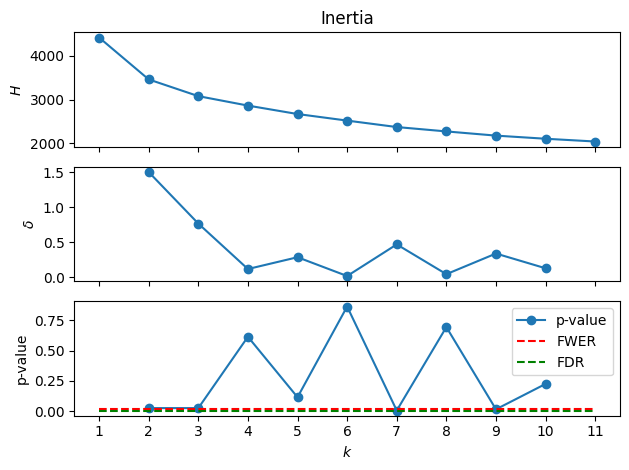

In [40]:
# Our models seem to struggle the most so far with the diabetes data set. Only kmeans with BBU select 
# k = 2 as significant. But k = 2 is quite close to being significant for agglomerative with BBU.

X = scaler.fit_transform(data_set.data)
agglomerative.fit(X)
agglomerative.find_significant_k(X, N=200)
agglomerative.plot()

In [41]:
agglomerative.show_significant_k()

FWER: [7]
FDR: [7]


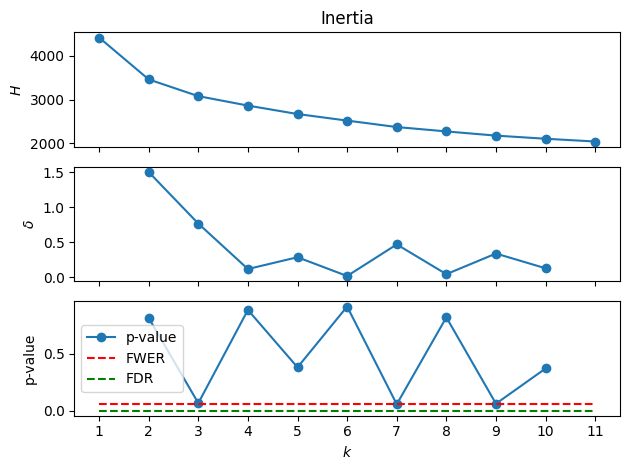

In [42]:
# Although with PCA, agglomerative gives k = 2 a much larger p-value.
agglomerative.fit(X)
agglomerative.find_significant_k(X, use_pca=True, N=200)
agglomerative.plot()

In [43]:
agglomerative.show_significant_k()

FWER: []
FDR: []


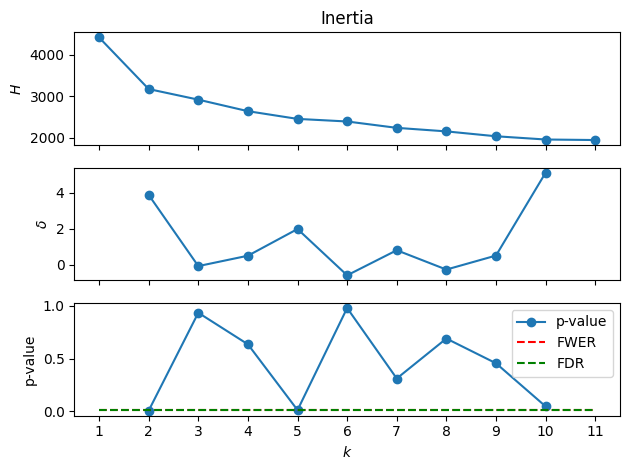

In [44]:
# And repeating kmeans with PCA does find k = 2 as significant.
kmeans.fit(X)
kmeans.find_significant_k(X, use_pca=True, N=200)
kmeans.plot()

In [45]:
kmeans.show_significant_k()

FWER: [2]
FDR: [2, 5]


In [ ]:
# Overall, kmeans and agglomerative models haved worked the best on the synthetic/real data used here.
# Also, it seems as though with only 200 monte-carlo simulations, the results have more variance
# than one would want. So a larger value of N should be used. And the results can vary some depending
# on whether the principle components are used or not for the monte-carlo simulations. Thus it seems
# ideal to try both kmeans and agglomerative with both BBU and PCA references when using the elbow
# statistic in practice. Well, out of the clustering models we've tried, anyway.